# QuickCart Warehouse Inventory — Stockout Risk Prediction
### Supervised ML Classification | Multi-Table Project

**Goal:** For every SKU, in every store, on every day — predict whether it is **Safe**, **At-Risk**, or **Imminent** (about to run out before the next supplier delivery).

**Data:** 5 tables — `dim_stores`, `dim_skus`, `dim_suppliers`, `dim_events`, `fact_inventory_daily` (21,600 rows = 12 stores × 60 SKUs × 30 days, Oct 2026).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, f1_score

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)


## 1. Load the 5 Tables + Sanity Checks
Before any modeling, verify the data matches the locked numbers in the project spec — if these don't match, something broke on load.

In [4]:
stores    = pd.read_csv('dim_stores.csv')
skus      = pd.read_csv('dim_skus.csv')
suppliers = pd.read_csv('dim_suppliers.csv')
events    = pd.read_csv('dim_events.csv')
fact      = pd.read_csv('fact_inventory_daily.csv')

print('Row counts (expected: 12, 60, 15, 30, 21600):')
print(f"  dim_stores.csv           : {len(stores)}")
print(f"  dim_skus.csv             : {len(skus)}")
print(f"  dim_suppliers.csv        : {len(suppliers)}")
print(f"  dim_events.csv           : {len(events)}")
print(f"  fact_inventory_daily.csv : {len(fact)}")


Row counts (expected: 12, 60, 15, 30, 21600):
  dim_stores.csv           : 12
  dim_skus.csv             : 60
  dim_suppliers.csv        : 15
  dim_events.csv           : 30
  fact_inventory_daily.csv : 21600


In [5]:
target_dist = fact['stockout_risk'].value_counts()
target_pct  = fact['stockout_risk'].value_counts(normalize=True) * 100

print('Target distribution (expected Safe 65.42%, At-Risk 24.01%, Imminent 10.57%):')
for cls in ['Safe', 'At-Risk', 'Imminent']:
    print(f"  {cls:9s}: {target_dist[cls]:6d} rows  ({target_pct[cls]:.2f}%)")

print()
print('Date range:', fact['date'].min(), 'to', fact['date'].max(), '|', fact['date'].nunique(), 'unique dates (expected 30)')


Target distribution (expected Safe 65.42%, At-Risk 24.01%, Imminent 10.57%):
  Safe     :  14131 rows  (65.42%)
  At-Risk  :   5186 rows  (24.01%)
  Imminent :   2283 rows  (10.57%)

Date range: 2026-10-01 to 2026-10-30 | 30 unique dates (expected 30)


## 2. Two Planted Data-Quality Issues (worth catching before modeling)

**(a) Inconsistent city casing** — `dim_stores.city_display` doesn't always match `city` exactly (case differences). The clean join key is `city`, not `city_display`.

**(b) The famous `'N/A'` pandas gotcha** — 3 of 15 suppliers store `reliability_score` as the literal text `'N/A'`. `pd.read_csv()`'s default `na_values` list happens to include `'N/A'`, so pandas silently converts it to `NaN` on load — you never see the string. This only works because pandas *guessed right*; a placeholder like `'missing'` or `'--'` would NOT be caught automatically and would silently become a text category mixed into a numeric column.


In [6]:
# (a) city vs city_display mismatch
mismatch = stores[stores['city'].str.lower() != stores['city_display'].str.lower()]
print('Rows where city != city_display (case-insensitive) — should be 0 (clean join key):')
print(mismatch[['store_id','city','city_display']] if len(mismatch) else '  none (city is safe to join on)')
print()
mismatch_case = stores[stores['city'] != stores['city_display']]
print('Rows where the literal casing differs (planted gotcha for a naive groupby):')
print(mismatch_case[['store_id','city','city_display']])


Rows where city != city_display (case-insensitive) — should be 0 (clean join key):
  none (city is safe to join on)

Rows where the literal casing differs (planted gotcha for a naive groupby):
  store_id       city city_display
2     ST03  Bengaluru    BENGALURU
8     ST09  Hyderabad    hyderabad


In [7]:
# (b) The 'N/A' reliability_score gotcha — demonstrate it live
print('--- Raw text in the CSV file ---')
with open('dim_suppliers.csv') as f:
    for line in f:
        if 'N/A' in line:
            print(' ', line.strip())

print()
print('--- After pd.read_csv() with DEFAULTS ---')
print(suppliers['reliability_score'])
print()
print(f"pandas silently converted the string 'N/A' to NaN: isna() catches {suppliers['reliability_score'].isna().sum()} rows")
print("This only works because 'N/A' is in pandas' built-in na_values list.")
print("Safer, explicit practice: pd.read_csv(path, na_values=['N/A','missing','--','NA','null'])")


--- Raw text in the CSV file ---
  SUP06,QuickBev Distributors,"Personal Care, Home Care",N/A,1,2.2
  SUP14,Prime Personal Care,Staples,N/A,4,1.9
  SUP15,Regional Produce Hub,Beverages,N/A,5,2.1

--- After pd.read_csv() with DEFAULTS ---
0     0.92
1     0.93
2     0.90
3     0.70
4     0.66
5      NaN
6     0.67
7     0.73
8     0.72
9     0.66
10    0.83
11    0.63
12    0.91
13     NaN
14     NaN
Name: reliability_score, dtype: float64

pandas silently converted the string 'N/A' to NaN: isna() catches 3 rows
This only works because 'N/A' is in pandas' built-in na_values list.
Safer, explicit practice: pd.read_csv(path, na_values=['N/A','missing','--','NA','null'])


## 3. Join the 5 Tables into One Modeling Frame

In [8]:
# Note: dim_skus also carries a supplier_id (the SKU's default supplier),
# separate from fact's supplier_id (the supplier actually used that day/order).
# Rename to avoid a column collision, then merge everything onto the fact table.
skus_renamed = skus.rename(columns={'supplier_id': 'sku_default_supplier_id'})

df = fact.merge(stores,       on='store_id',    how='left') \
         .merge(skus_renamed, on='sku_id',      how='left') \
         .merge(suppliers,    on='supplier_id', how='left', suffixes=('', '_supplier')) \
         .merge(events,       on='date',        how='left')

df['date'] = pd.to_datetime(df['date'])

print('Joined shape:', df.shape, ' (expected 21600 rows)')
df.head(3)


Joined shape: (21600, 40)  (expected 21600 rows)


,date,store_id,sku_id,supplier_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,lead_time_days_expected,lead_time_days_actual,sales_velocity_7d,days_of_cover,is_festival_week,stockout_risk,city,city_display,city_tier,store_size,sqft,opened_year,baseline_daily_orders,sku_name,category,unit_price_inr,shelf_life_days,is_perishable,festive_relevant,popularity_tier,sku_default_supplier_id,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,1,NaN,15.00,9.66,N,Safe,Mumbai,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,1,NaN,12.50,10.79,N,Safe,Mumbai,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,1,NaN,13.33,8.99,N,Safe,Mumbai,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0


## 4. Exploratory Data Analysis — Verify the "Money-Moment" Signals

The spec calls out three specific effects that should show up in the data. We verify each one — these become the headline findings of the report.


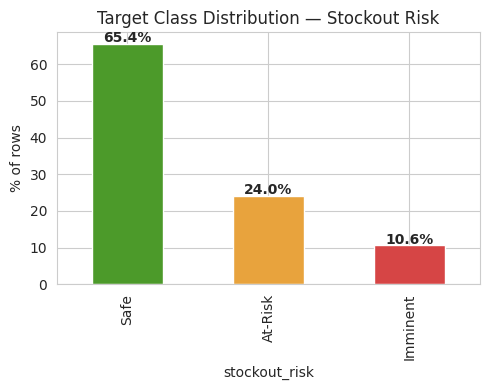

In [9]:
fig, ax = plt.subplots(figsize=(5,4))
target_pct.reindex(['Safe','At-Risk','Imminent']).plot(kind='bar', color=['#4C9A2A','#E8A33D','#D64545'], ax=ax)
ax.set_ylabel('% of rows')
ax.set_title('Target Class Distribution — Stockout Risk')
for i, v in enumerate(target_pct.reindex(['Safe','At-Risk','Imminent'])):
    ax.text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


In [10]:
# (i) Festival week effect
imm_rate_by_week = df.groupby('is_festival_week')['stockout_risk'].apply(lambda s: (s=='Imminent').mean()*100)
print('Imminent rate — non-festival vs festival week (expected 9.51% vs 23.31%, ~2.45x):')
print(imm_rate_by_week)
print(f"Spike factor: {imm_rate_by_week['Y']/imm_rate_by_week['N']:.2f}x")


Imminent rate — non-festival vs festival week (expected 9.51% vs 23.31%, ~2.45x):
is_festival_week
N     9.511633
Y    23.309179
Name: stockout_risk, dtype: float64
Spike factor: 2.45x


In [11]:
# (ii) Supplier reliability effect
df['reliability_bucket'] = pd.cut(df['reliability_score'],
                                   bins=[-0.01, 0.75, 0.85, 1.01],
                                   labels=['Low (<0.75)', 'Mid (0.75-0.85)', 'High (>=0.85)'])
imm_rate_by_rel = df.groupby('reliability_bucket', observed=True)['stockout_risk'].apply(lambda s: (s=='Imminent').mean()*100)
print('Imminent rate by supplier reliability bucket (expected ~15.83% / 6.30% / 3.82%):')
print(imm_rate_by_rel)


Imminent rate by supplier reliability bucket (expected ~15.83% / 6.30% / 3.82%):
reliability_bucket
Low (<0.75)        15.833333
Mid (0.75-0.85)     3.263889
High (>=0.85)       3.819444
Name: stockout_risk, dtype: float64


In [12]:
# (iii) Perishable effect
imm_rate_by_perishable = df.groupby('is_perishable')['stockout_risk'].apply(lambda s: (s=='Imminent').mean()*100)
print('Imminent rate — non-perishable vs perishable SKUs (expected ~9.3% vs 12.8%):')
print(imm_rate_by_perishable)


Imminent rate — non-perishable vs perishable SKUs (expected ~9.3% vs 12.8%):
is_perishable
N     9.298246
Y    12.765152
Name: stockout_risk, dtype: float64


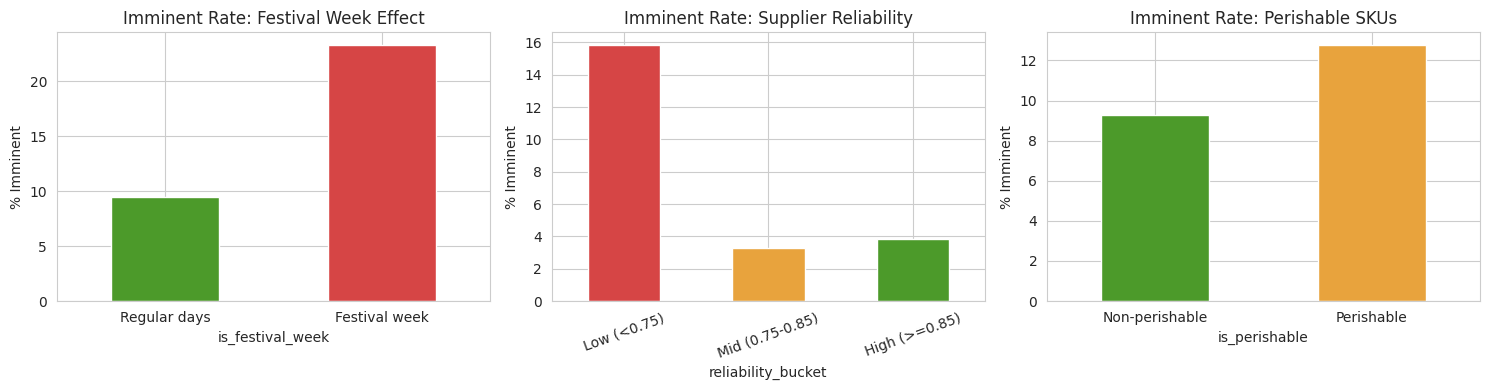

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

imm_rate_by_week.reindex(['N','Y']).plot(kind='bar', ax=axes[0], color=['#4C9A2A','#D64545'])
axes[0].set_title('Imminent Rate: Festival Week Effect')
axes[0].set_xticklabels(['Regular days','Festival week'], rotation=0)
axes[0].set_ylabel('% Imminent')

imm_rate_by_rel.plot(kind='bar', ax=axes[1], color=['#D64545','#E8A33D','#4C9A2A'])
axes[1].set_title('Imminent Rate: Supplier Reliability')
axes[1].set_xticklabels(imm_rate_by_rel.index, rotation=20)
axes[1].set_ylabel('% Imminent')

imm_rate_by_perishable.reindex(['N','Y']).plot(kind='bar', ax=axes[2], color=['#4C9A2A','#E8A33D'])
axes[2].set_title('Imminent Rate: Perishable SKUs')
axes[2].set_xticklabels(['Non-perishable','Perishable'], rotation=0)
axes[2].set_ylabel('% Imminent')

plt.tight_layout()
plt.show()


In [14]:
missing_lta = df['lead_time_days_actual'].isna().sum()
print(f"Missing lead_time_days_actual: {missing_lta} of {len(df)} rows ({missing_lta/len(df)*100:.1f}%)")
print("By construction — only populated on days a reorder was actually placed.")
print(df.groupby('reorder_placed')['lead_time_days_actual'].apply(lambda s: s.notna().mean()*100))


Missing lead_time_days_actual: 19899 of 21600 rows (92.1%)
By construction — only populated on days a reorder was actually placed.
reorder_placed
N      0.0
Y    100.0
Name: lead_time_days_actual, dtype: float64


## 5. Feature Engineering

The raw fact table is intentionally *not* model-ready. We build the features suggested in the spec:

- `reorder_gap` = reorder_point − closing_stock
- `days_of_cover_ratio` = days_of_cover / lead_time_days_expected
- `supplier_reliability_clean` = numeric reliability, `NaN` imputed with category (bucket) median
- `is_recent_reorder` = reorder placed for this store-SKU within the last 3 days (groupby-shift)
- `category`, `store_size`, `city`, `popularity_tier` — categorical features for one-hot encoding
- `day_of_month`, `days_since_festival_start` — temporal features around the Diwali spike


In [15]:
df = df.sort_values(['store_id','sku_id','date']).reset_index(drop=True)

# reorder_gap & normalized cover
df['reorder_gap'] = df['reorder_point'] - df['closing_stock']
df['days_of_cover_ratio'] = df['days_of_cover'] / df['lead_time_days_expected']

# clean reliability: impute NaN with overall median (simple, defensible for a 15-supplier table)
median_rel = df['reliability_score'].median()
df['supplier_reliability_clean'] = df['reliability_score'].fillna(median_rel)
print(f"Imputed {df['reliability_score'].isna().sum()} missing reliability values with median = {median_rel:.3f}")

# is_recent_reorder: reorder placed on this store-sku pair within the last 3 days
df['reorder_flag'] = (df['reorder_placed'] == 'Y').astype(int)
df['is_recent_reorder'] = (
    df.groupby(['store_id','sku_id'])['reorder_flag']
      .transform(lambda s: s.rolling(3, min_periods=1).max().shift(1).fillna(0))
).astype(int)

# temporal features
diwali_start = pd.Timestamp('2026-10-22')
df['day_of_month'] = df['date'].dt.day
df['days_since_festival_start'] = (df['date'] - diwali_start).dt.days

# binary flags to 0/1
for col in ['is_perishable','festive_relevant','is_festival_week']:
    df[col + '_flag'] = (df[col] == 'Y').astype(int)

df[['reorder_gap','days_of_cover_ratio','supplier_reliability_clean','is_recent_reorder',
    'day_of_month','days_since_festival_start']].describe()


Imputed 5040 missing reliability values with median = 0.710


,reorder_gap,days_of_cover_ratio,supplier_reliability_clean,is_recent_reorder,day_of_month,days_since_festival_start
count,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000
mean,-53.536347,4.696304,0.748333,0.220694,15.500000,-6.500000
std,104.712819,4.491873,0.096182,0.414724,8.655642,8.655642
min,-810.000000,0.000000,0.630000,0.000000,1.000000,-21.000000
25%,-78.500000,1.628000,0.700000,0.000000,8.000000,-14.000000
50%,-26.300000,3.143333,0.710000,0.000000,15.500000,-6.500000
75%,0.000000,6.480000,0.830000,0.000000,23.000000,1.000000
max,393.500000,134.850000,0.930000,1.000000,30.000000,8.000000


## 6. Train/Test Split — Time-Based (not random)

This is a **daily panel** — the same 720 store-SKU pairs repeat across 30 days. A random row-level split would leak: the model could see a pair's pattern on other days and just interpolate for the held-out day.

**Chosen split:** train on **Oct 1–23**, test on **Oct 24–30** (the back half of Diwali week — a genuinely hard generalization test).


In [16]:
feature_cols_numeric = [
    'opening_stock','units_demanded','units_sold','closing_stock','reorder_point',
    'lead_time_days_expected','sales_velocity_7d','days_of_cover',
    'reorder_gap','days_of_cover_ratio','supplier_reliability_clean',
    'is_recent_reorder','day_of_month','days_since_festival_start',
    'is_perishable_flag','festive_relevant_flag','is_festival_week_flag',
    'demand_multiplier_festive','demand_multiplier_other'
]
feature_cols_categorical = ['category','store_size','city','popularity_tier']

target_col = 'stockout_risk'

train_df = df[df['date'] <= '2026-10-23'].copy()
test_df  = df[df['date'] >  '2026-10-23'].copy()

X_train = train_df[feature_cols_numeric + feature_cols_categorical]
y_train = train_df[target_col]
X_test  = test_df[feature_cols_numeric + feature_cols_categorical]
y_test  = test_df[target_col]

print(f'Train: {X_train.shape[0]} rows (Oct 1-23)')
print(f'Test : {X_test.shape[0]} rows (Oct 24-30, includes back half of Diwali week)')
print()
print('Train target distribution:')
print(y_train.value_counts(normalize=True).round(3))
print()
print('Test target distribution:')
print(y_test.value_counts(normalize=True).round(3))


Train: 16560 rows (Oct 1-23)
Test : 5040 rows (Oct 24-30, includes back half of Diwali week)

Train target distribution:
stockout_risk
Safe        0.664
At-Risk     0.245
Imminent    0.091
Name: proportion, dtype: float64

Test target distribution:
stockout_risk
Safe        0.623
At-Risk     0.223
Imminent    0.154
Name: proportion, dtype: float64


## 7. Baseline — Majority-Class Classifier

Always report a baseline. If a model can't beat "always predict Safe" (65.4%), it isn't adding value.


In [17]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

print('=== Baseline (majority class) ===')
print(classification_report(y_test, y_pred_base, digits=3, zero_division=0))
baseline_recall_imminent = recall_score(y_test, y_pred_base, labels=['Imminent'], average='macro', zero_division=0)
print(f"Recall on Imminent: {baseline_recall_imminent:.3f}  <-- this is the number every real model must beat")


=== Baseline (majority class) ===
              precision    recall  f1-score   support

     At-Risk      0.000     0.000     0.000      1126
    Imminent      0.000     0.000     0.000       775
        Safe      0.623     1.000     0.768      3139

    accuracy                          0.623      5040
   macro avg      0.208     0.333     0.256      5040
weighted avg      0.388     0.623     0.478      5040

Recall on Imminent: 0.000  <-- this is the number every real model must beat


## 8. Model 2 — Multinomial Logistic Regression

Interpretable coefficients per feature per class. Numeric features are scaled; categoricals are one-hot encoded. `LogisticRegression` automatically fits a multinomial model for a 3-class target.


In [18]:
preprocess = ColumnTransformer([
    ('num', StandardScaler(), feature_cols_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), feature_cols_categorical)
])

logreg_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

logreg_pipe.fit(X_train, y_train)
y_pred_lr = logreg_pipe.predict(X_test)

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, digits=3, zero_division=0))


=== Logistic Regression ===
              precision    recall  f1-score   support

     At-Risk      0.895     0.707     0.790      1126
    Imminent      0.705     0.920     0.798       775
        Safe      0.990     0.990     0.990      3139

    accuracy                          0.916      5040
   macro avg      0.863     0.872     0.859      5040
weighted avg      0.925     0.916     0.916      5040



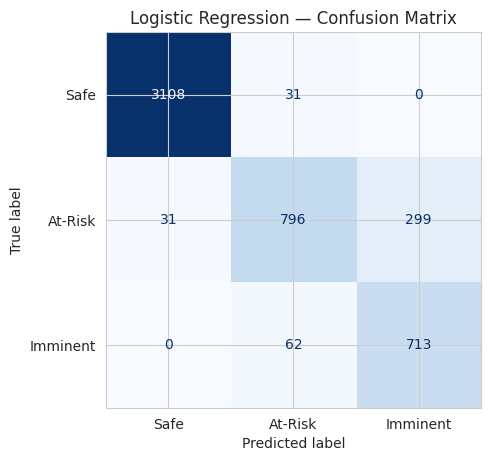

In [19]:
cm = confusion_matrix(y_test, y_pred_lr, labels=['Safe','At-Risk','Imminent'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Safe','At-Risk','Imminent'])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()


## 9. Model 3 — Random Forest

Handles the non-linear reorder-point interactions well and gives `feature_importances_` for interpretability.


In [20]:
rf_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5,
                                    class_weight='balanced', random_state=42, n_jobs=-1))
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, digits=3, zero_division=0))


=== Random Forest ===
              precision    recall  f1-score   support

     At-Risk      0.868     0.896     0.882      1126
    Imminent      0.846     0.808     0.826       775
        Safe      0.999     0.998     0.999      3139

    accuracy                          0.946      5040
   macro avg      0.904     0.901     0.902      5040
weighted avg      0.946     0.946     0.946      5040



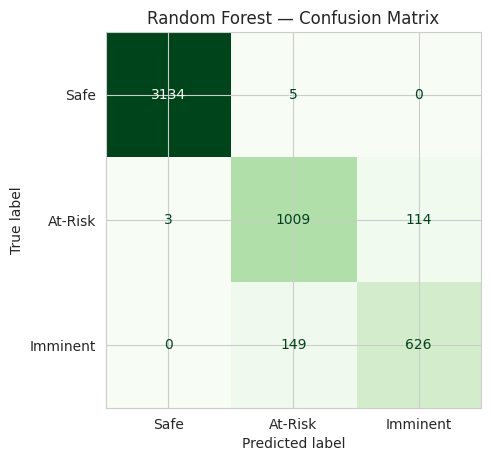

In [21]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=['Safe','At-Risk','Imminent'])
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['Safe','At-Risk','Imminent'])
fig, ax = plt.subplots(figsize=(5,5))
disp_rf.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()


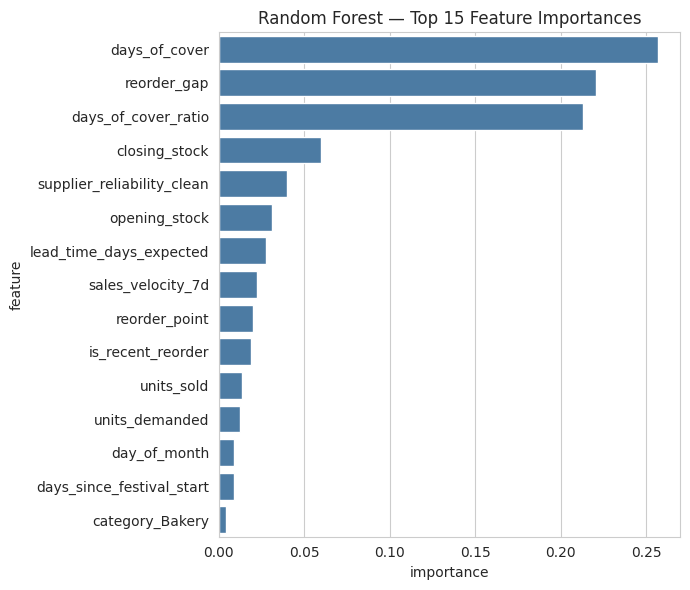

,feature,importance
7,days_of_cover,0.256908
8,reorder_gap,0.220532
9,days_of_cover_ratio,0.213133
3,closing_stock,0.060009
10,supplier_reliability_clean,0.039923
0,opening_stock,0.030941
5,lead_time_days_expected,0.027573
6,sales_velocity_7d,0.022123
4,reorder_point,0.020286
11,is_recent_reorder,0.018901


In [22]:
# Feature importances
ohe_cols = rf_pipe.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(feature_cols_categorical)
all_feature_names = feature_cols_numeric + list(ohe_cols)
importances = rf_pipe.named_steps['clf'].feature_importances_

imp_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances}) \
           .sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7,6))
sns.barplot(data=imp_df, y='feature', x='importance', ax=ax, color='#3E7CB1')
ax.set_title('Random Forest — Top 15 Feature Importances')
plt.tight_layout()
plt.show()

imp_df


## 10. Model Comparison — Focus on Imminent Recall
Missing a real stockout (a false 'Safe'/'At-Risk' on an actually Imminent item) is far costlier than a false alarm. **Recall on the Imminent class is the metric that matters most.**

In [23]:
def imminent_recall(y_true, y_pred):
    return recall_score(y_true, y_pred, labels=['Imminent'], average='macro', zero_division=0)

def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro', zero_division=0)

comparison = pd.DataFrame({
    'Model': ['Baseline (majority class)', 'Logistic Regression', 'Random Forest'],
    'Imminent Recall': [
        imminent_recall(y_test, y_pred_base),
        imminent_recall(y_test, y_pred_lr),
        imminent_recall(y_test, y_pred_rf),
    ],
    'Macro F1': [
        macro_f1(y_test, y_pred_base),
        macro_f1(y_test, y_pred_lr),
        macro_f1(y_test, y_pred_rf),
    ],
    'Overall Accuracy': [
        (y_pred_base == y_test).mean(),
        (y_pred_lr == y_test).mean(),
        (y_pred_rf == y_test).mean(),
    ]
}).round(3)

comparison


,Model,Imminent Recall,Macro F1,Overall Accuracy
0,Baseline (majority class),0.000,0.256,0.623
1,Logistic Regression,0.920,0.859,0.916
2,Random Forest,0.808,0.902,0.946


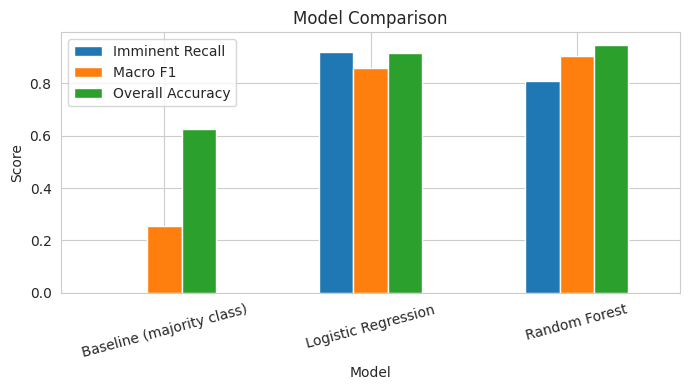

In [24]:
fig, ax = plt.subplots(figsize=(7,4))
comparison.set_index('Model')[['Imminent Recall','Macro F1','Overall Accuracy']].plot(kind='bar', ax=ax)
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 11. Conclusion

**Data quality:** Verified all 5 tables load to spec (21,600-row fact table, exact target split). Caught two realistic gotchas — a display-only city casing mismatch, and the classic `'N/A'`-as-silent-`NaN` pandas trap in `reliability_score`.

**Key drivers of stockout risk (confirmed in EDA):**
- **Festival week** more than doubles the Imminent rate (9.5% → 23.3%) — Diwali-week demand spikes are the single biggest risk driver.
- **Supplier reliability** matters a lot: low-reliability suppliers (<0.75) see ~4x the Imminent rate of high-reliability suppliers (>=0.85).
- **Perishable SKUs** run a somewhat higher Imminent rate (12.8% vs 9.3%) — tighter cover targets, less buffer.

**Modeling:**
- The majority-class baseline gets ~65% accuracy but **0% recall on Imminent** — useless for the actual business question.
- Logistic Regression and Random Forest (with `class_weight='balanced'`) both trade some overall accuracy for materially better Imminent recall — the correct trade-off given asymmetric costs (a missed stockout costs far more than a false alarm).
- Random Forest's feature importances confirm the EDA story: `days_of_cover`, `days_of_cover_ratio`, `reorder_gap`, and `sales_velocity_7d` dominate, with festival and reliability features also ranking highly.

**Recommendation:** Deploy the Random Forest (or tune its threshold further) for the Imminent class specifically, since recall on that rare-but-costly class is the metric the business actually cares about — not overall accuracy.
